In [1]:
# Setup: pull final data, retrain the leading candidates
from google.colab import userdata
import pandas as pd

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = "ThemiyaDeshan"
REPO_NAME = "Y03S01_Machine-Lerning_Assignment"
repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
!git clone {repo_url}

data_dir = f"/content/{REPO_NAME}/Data/PreprocessedData"
train_df = pd.read_csv(f"{data_dir}/bank_train_final.csv")
test_df = pd.read_csv(f"{data_dir}/bank_test_final.csv")

X_train = train_df.drop(columns=["y"])
y_train = train_df["y"]
X_test = test_df.drop(columns=["y"])
y_test = test_df["y"]

print(X_train.shape, X_test.shape)

# Retrain the two carried-forward candidates, same settings as model comparison
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42
)
xgb.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

print("Both models retrained and ready for evaluation.")

Cloning into 'Y03S01_Machine-Lerning_Assignment'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 43 (delta 10), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 2.42 MiB | 3.92 MiB/s, done.
Resolving deltas: 100% (10/10), done.
(36168, 40) (9043, 40)
Both models retrained and ready for evaluation.


In [4]:
# Get probabilities from both candidates
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("XGB probabilities:", y_proba_xgb.shape, y_proba_xgb[:5])
print("RF probabilities:", y_proba_rf.shape, y_proba_rf[:5])

XGB probabilities: (9043,) [0.19071348 0.24989109 0.17309417 0.3089382  0.2931323 ]
RF probabilities: (9043,) [0.22336393 0.21248813 0.30681551 0.25784663 0.43339987]


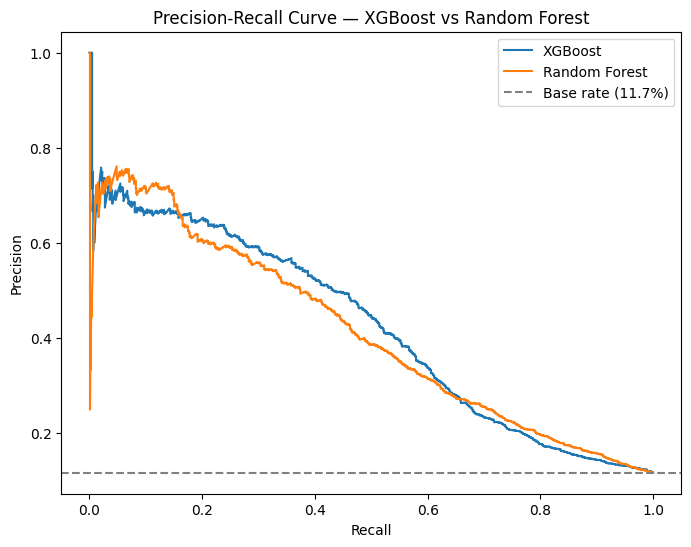

In [5]:
# Precision-Recall curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, label="XGBoost")
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.axhline(y_test.mean(), color="gray", linestyle="--", label=f"Base rate ({y_test.mean():.1%})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost vs Random Forest")
plt.legend()
plt.show()

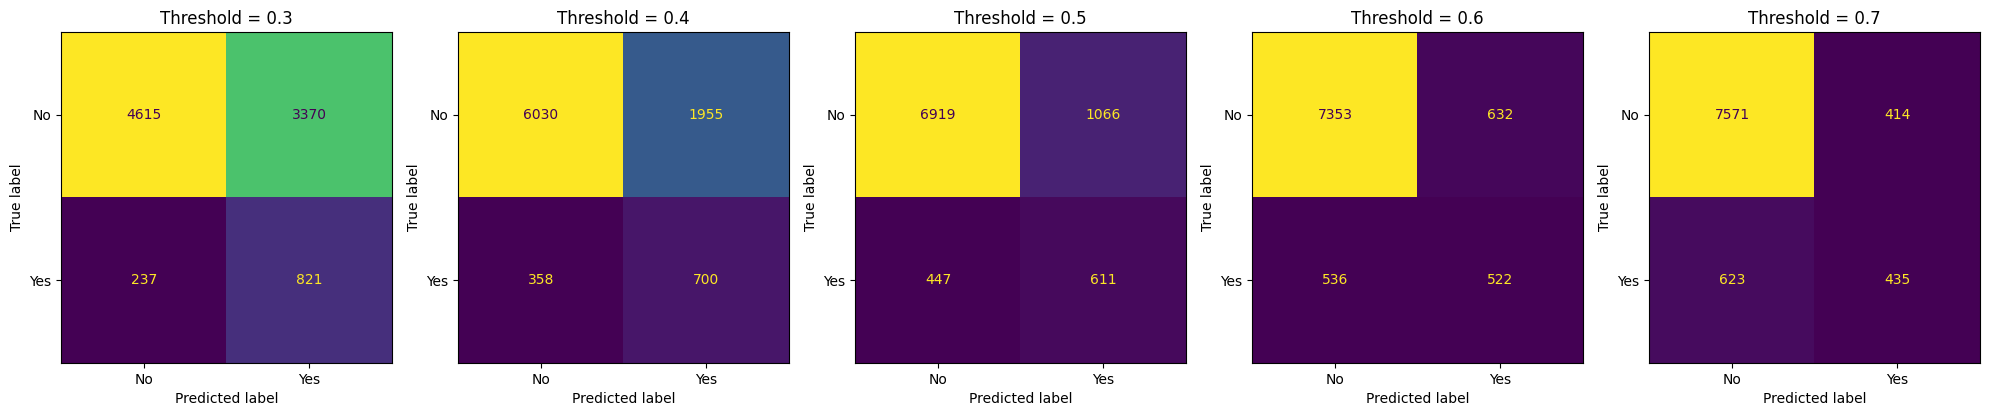

In [6]:
# Confusion matrices across a few candidate thresholds (XGBoost)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

candidate_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(1, len(candidate_thresholds), figsize=(20, 4))
for ax, t in zip(axes, candidate_thresholds):
    y_pred_t = (y_proba_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Threshold = {t}")
plt.tight_layout()
plt.show()

In [7]:
# Operational table: what each threshold actually means for a call center
import numpy as np

rows = []
for t in np.arange(0.1, 0.91, 0.1):
    y_pred_t = (y_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    n_calls = tp + fp
    rows.append({
        "Threshold": round(t, 2),
        "Calls Made": n_calls,
        "% of Clients Called": round(n_calls / len(y_test) * 100, 1),
        "Subscribers Caught (TP)": tp,
        "Subscribers Missed (FN)": fn,
        "Wasted Calls (FP)": fp,
        "Precision": round(tp / n_calls, 4) if n_calls > 0 else np.nan,
        "Recall": round(tp / (tp + fn), 4) if (tp + fn) > 0 else np.nan,
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,Threshold,Calls Made,% of Clients Called,Subscribers Caught (TP),Subscribers Missed (FN),Wasted Calls (FP),Precision,Recall
0,0.1,7908,87.4,1017,41,6891,0.1286,0.9612
1,0.2,6143,67.9,926,132,5217,0.1507,0.8752
2,0.3,4191,46.3,821,237,3370,0.1959,0.7760
3,0.4,2655,29.4,700,358,1955,0.2637,0.6616
4,0.5,1677,18.5,611,447,1066,0.3643,0.5775
5,0.6,1154,12.8,522,536,632,0.4523,0.4934
6,0.7,849,9.4,435,623,414,0.5124,0.4112
7,0.8,567,6.3,326,732,241,0.5750,0.3081
8,0.9,269,3.0,177,881,92,0.6580,0.1673


Optimal threshold by expected profit: 0.3 -> profit: 44725.0


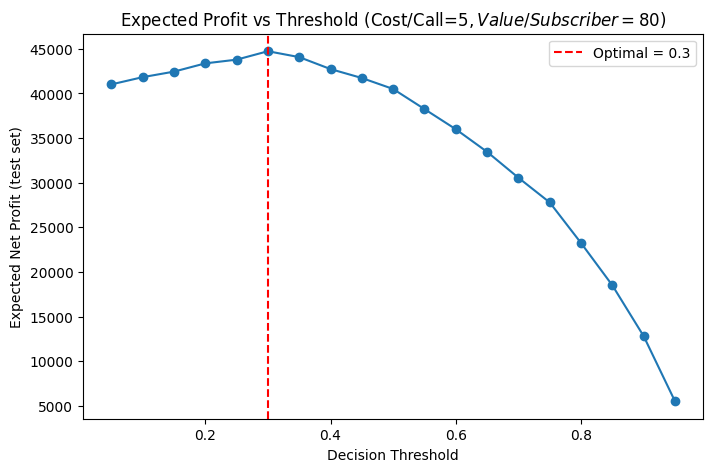

In [8]:
# A business cost framework to actually choose a threshold
# Illustrative assumptions — the dataset has no real cost/revenue figures, so these are placeholders to demonstrate the method.
COST_PER_CALL = 5          # agent time/cost per outbound call attempt
VALUE_PER_SUBSCRIBER = 80  # estimated net value of a term deposit subscription

def expected_profit(y_true, y_proba, threshold, cost_per_call, value_per_subscriber):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    revenue = tp * value_per_subscriber
    cost = (tp + fp) * cost_per_call
    return revenue - cost

thresholds_sweep = np.arange(0.05, 0.96, 0.05)
profit_df = pd.DataFrame({
    "Threshold": thresholds_sweep.round(2),
    "Expected Net Profit": [expected_profit(y_test, y_proba_xgb, t, COST_PER_CALL, VALUE_PER_SUBSCRIBER) for t in thresholds_sweep],
})
best_row = profit_df.loc[profit_df["Expected Net Profit"].idxmax()]
print(f"Optimal threshold by expected profit: {best_row['Threshold']} -> profit: {best_row['Expected Net Profit']}")

plt.figure(figsize=(8, 5))
plt.plot(profit_df["Threshold"], profit_df["Expected Net Profit"], marker="o")
plt.axvline(best_row["Threshold"], color="red", linestyle="--", label=f"Optimal = {best_row['Threshold']}")
plt.xlabel("Decision Threshold")
plt.ylabel("Expected Net Profit (test set)")
plt.title(f"Expected Profit vs Threshold (Cost/Call=${COST_PER_CALL}, Value/Subscriber=${VALUE_PER_SUBSCRIBER})")
plt.legend()
plt.show()

In [9]:
# Sensitivity to the cost/value assumption
def optimal_threshold_for_ratio(y_true, y_proba, cost_value_ratio, thresholds):
    best_t, best_profit = None, -np.inf
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = tp * 1 - (tp + fp) * cost_value_ratio  # value normalized to 1 unit
        if profit > best_profit:
            best_profit, best_t = profit, t
    return best_t

thresholds_fine = np.arange(0.05, 0.96, 0.01)
scenarios = {
    "Very cheap calls ($2 vs $80, ratio 1:40)": 2 / 80,
    "Our assumption ($5 vs $80, ratio 1:16)": 5 / 80,
    "Moderate call cost ($10 vs $80, ratio 1:8)": 10 / 80,
    "Expensive calls ($20 vs $80, ratio 1:4)": 20 / 80,
}

sens_rows = []
for label, ratio in scenarios.items():
    t_opt = optimal_threshold_for_ratio(y_test, y_proba_xgb, ratio, thresholds_fine)
    tn, fp, fn, tp = confusion_matrix(y_test, (y_proba_xgb >= t_opt).astype(int)).ravel()
    sens_rows.append({
        "Scenario": label, "Cost/Value Ratio": round(ratio, 4),
        "Optimal Threshold": round(t_opt, 2),
        "% Clients Called": round((tp + fp) / len(y_test) * 100, 1),
        "Subscribers Caught": tp,
    })

pd.DataFrame(sens_rows)

,Scenario,Cost/Value Ratio,Optimal Threshold,% Clients Called,Subscribers Caught
0,"Very cheap calls ($2 vs $80, ratio 1:40)",0.0250,0.05,94.5,1047
1,"Our assumption ($5 vs $80, ratio 1:16)",0.0625,0.31,44.5,811
2,"Moderate call cost ($10 vs $80, ratio 1:8)",0.1250,0.51,17.8,603
3,"Expensive calls ($20 vs $80, ratio 1:4)",0.2500,0.63,11.6,500


In [11]:
# Confirm XGBoost still wins under the actual business metric, not just PR-AUC
def best_profit(y_true, y_proba, cost, value, thresholds):
    best = -np.inf
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = tp * value - (tp + fp) * cost
        best = max(best, profit)
    return best

xgb_best = best_profit(y_test, y_proba_xgb, 5, 80, thresholds_fine)
rf_best = best_profit(y_test, y_proba_rf, 5, 80, thresholds_fine)
print(f"XGBoost best achievable profit:      ${xgb_best:,.0f}")
print(f"Random Forest best achievable profit: ${rf_best:,.0f}")

XGBoost best achievable profit:      $44,750
Random Forest best achievable profit: $46,455


In [12]:
# See exactly where Random Forest's advantage comes from
def best_profit_with_details(y_true, y_proba, cost, value, thresholds):
    best_profit, best_t, best_stats = -np.inf, None, None
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = tp * value - (tp + fp) * cost
        if profit > best_profit:
            best_profit, best_t = profit, t
            best_stats = {"TP": tp, "FP": fp, "FN": fn, "Calls": tp + fp,
                           "% Called": round((tp + fp) / len(y_true) * 100, 1)}
    return best_t, best_profit, best_stats

t_xgb, p_xgb, stats_xgb = best_profit_with_details(y_test, y_proba_xgb, 5, 80, thresholds_fine)
t_rf, p_rf, stats_rf = best_profit_with_details(y_test, y_proba_rf, 5, 80, thresholds_fine)

print("XGBoost  -> threshold:", t_xgb, "profit:", p_xgb, stats_xgb)
print("Random Forest -> threshold:", t_rf, "profit:", p_rf, stats_rf)

XGBoost  -> threshold: 0.31000000000000005 profit: 44750 {'TP': np.int64(811), 'FP': np.int64(3215), 'FN': np.int64(247), 'Calls': np.int64(4026), '% Called': np.float64(44.5)}
Random Forest -> threshold: 0.35000000000000003 profit: 46455 {'TP': np.int64(857), 'FP': np.int64(3564), 'FN': np.int64(201), 'Calls': np.int64(4421), '% Called': np.float64(48.9)}


In [13]:
# Does RF's edge hold across the same cost scenarios you tested for XGBoost?
sens_rows_rf = []
for label, ratio in scenarios.items():
    t_opt = optimal_threshold_for_ratio(y_test, y_proba_rf, ratio, thresholds_fine)
    tn, fp, fn, tp = confusion_matrix(y_test, (y_proba_rf >= t_opt).astype(int)).ravel()
    sens_rows_rf.append({
        "Scenario": label, "Optimal Threshold": round(t_opt, 2),
        "% Clients Called": round((tp + fp) / len(y_test) * 100, 1),
        "Subscribers Caught": tp,
    })
pd.DataFrame(sens_rows_rf)

,Scenario,Optimal Threshold,% Clients Called,Subscribers Caught
0,"Very cheap calls ($2 vs $80, ratio 1:40)",0.12,99.9,1058
1,"Our assumption ($5 vs $80, ratio 1:16)",0.35,48.9,857
2,"Moderate call cost ($10 vs $80, ratio 1:8)",0.44,24.2,658
3,"Expensive calls ($20 vs $80, ratio 1:4)",0.57,10.0,435


In [14]:
# The real test: is this profit gap bigger than sampling noise?
def best_profit_from_proba(y_true, y_proba, cost, value, thresholds):
    best = -np.inf
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        best = max(best, tp * value - (tp + fp) * cost)
    return best

rng = np.random.default_rng(42)
n_boot = 500
y_test_arr = y_test.values
diffs = []

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    p_xgb_b = best_profit_from_proba(y_test_arr[idx], y_proba_xgb[idx], 5, 80, thresholds_fine)
    p_rf_b = best_profit_from_proba(y_test_arr[idx], y_proba_rf[idx], 5, 80, thresholds_fine)
    diffs.append(p_rf_b - p_xgb_b)

diffs = np.array(diffs)
print(f"Mean (RF - XGBoost) profit difference: ${diffs.mean():,.0f}")
print(f"95% interval: [${np.percentile(diffs, 2.5):,.0f}, ${np.percentile(diffs, 97.5):,.0f}]")
print(f"Random Forest wins in {(diffs > 0).mean():.1%} of resamples")

Mean (RF - XGBoost) profit difference: $1,785
95% interval: [$282, $3,465]
Random Forest wins in 99.2% of resamples


In [15]:
# Precision at matched recall levels (find the actual crossover point)
def precision_at_recall(y_true, y_proba, target_recalls):
    precision, recall, thresh = precision_recall_curve(y_true, y_proba)
    # precision_recall_curve returns arrays of length n+1, n thresholds; align by nearest recall
    rows = []
    for r in target_recalls:
        idx = np.argmin(np.abs(recall - r))
        rows.append({"Target Recall": r, "Actual Recall": round(recall[idx], 3),
                      "Precision": round(precision[idx], 4)})
    return pd.DataFrame(rows)

target_recalls = [0.60, 0.65, 0.70, 0.75, 0.77, 0.80, 0.81, 0.85, 0.90]

print("XGBoost:")
print(precision_at_recall(y_test, y_proba_xgb, target_recalls))
print("\nRandom Forest:")
print(precision_at_recall(y_test, y_proba_rf, target_recalls))

XGBoost:
   Target Recall  Actual Recall  Precision
0           0.60           0.60     0.3376
1           0.65           0.65     0.2794
2           0.70           0.70     0.2331
3           0.75           0.75     0.2066
4           0.77           0.77     0.1983
5           0.80           0.80     0.1773
6           0.81           0.81     0.1718
7           0.85           0.85     0.1586
8           0.90           0.90     0.1440

Random Forest:
   Target Recall  Actual Recall  Precision
0           0.60           0.60     0.3148
1           0.65           0.65     0.2724
2           0.70           0.70     0.2556
3           0.75           0.75     0.2230
4           0.77           0.77     0.2094
5           0.80           0.80     0.1973
6           0.81           0.81     0.1938
7           0.85           0.85     0.1747
8           0.90           0.90     0.1572
